<a href="https://colab.research.google.com/github/oliraman9031/Buggy/blob/main/Dog_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

### Getting our workspace ready so that we could get the section part

End to End dog Breed classification from kaggle

In [ ]:
# !unzip "/content/drive/MyDrive/Classroom/dog-breed-identification.zip" -d "/content/drive/MyDrive/Classroom/"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf

In [ ]:
import tensorflow_hub as hub
print("Tensor flow hub version: ",hub.__version__)

Tensor flow hub version:  0.16.1


In [ ]:
print("Tensorflow: ", tf.__version__)

Tensorflow:  2.20.0


# Getting our data ready turningn our images into tensors.

In [ ]:
#Check out th elabels of our data

In [ ]:
import pandas as pd
labels_csv=pd.read_csv("/content/drive/MyDrive/Classroom/labels.csv")

In [ ]:
# /content/drive/MyDrive/Classroom/labels.csv

In [ ]:
print(labels_csv.describe())
labels_csv.head()

                                      id               breed
count                              10222               10222
unique                             10222                 120
top     fff43b07992508bc822f33d8ffd902ae  scottish_deerhound
freq                                   1                 126


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [ ]:
# how many images aer there for each breeed

In [ ]:
labels_csv["breed"].value_counts()

,count
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114
...,...
golden_retriever,67
komondor,67
brabancon_griffon,67


<Axes: xlabel='breed'>

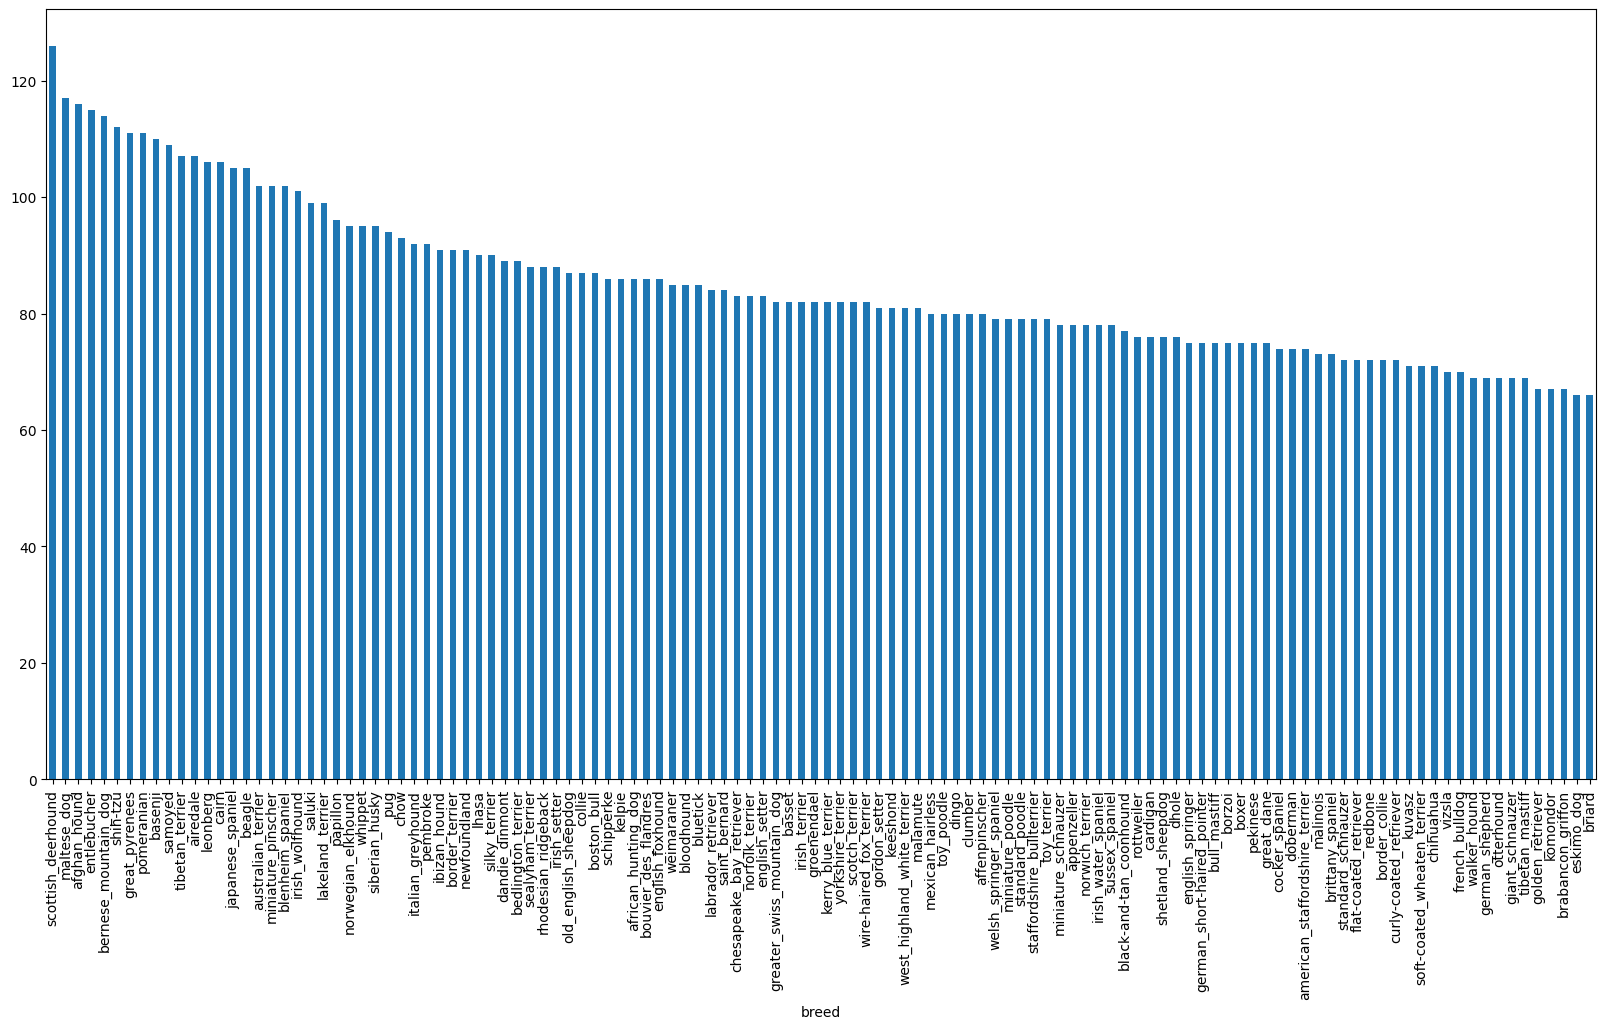

In [ ]:
labels_csv["breed"].value_counts().plot.bar(figsize=(20,10))

In [ ]:
labels_csv["breed"].value_counts().median()

82.0

lets view our image

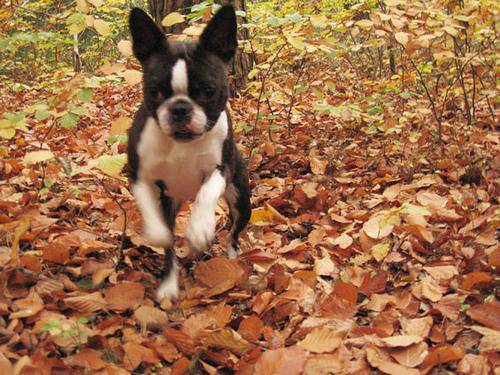

In [ ]:
from IPython.display import Image
Image("/content/drive/MyDrive/Classroom/train/000bec180eb18c7604dcecc8fe0dba07.jpg")

In [ ]:
### Getting images and their labels lets get a list of our image file path names

In [ ]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [ ]:
filenames=["/content/drive/MyDrive/Classroom/train/"+ fname + ".jpg" for fname in labels_csv["id"]]
filenames[:5]

['/content/drive/MyDrive/Classroom/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/content/drive/MyDrive/Classroom/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/content/drive/MyDrive/Classroom/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/content/drive/MyDrive/Classroom/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/content/drive/MyDrive/Classroom/train/0021f9ceb3235effd7fcde7f7538ed62.jpg']

In [ ]:
#Check whether the number of filenames matches matches the number of image files

In [ ]:
import os
if len(os.listdir("/content/drive/MyDrive/Classroom/train/")) == len(filenames):
  print("Filenames match actual amount of files !! Proceed")
else:
  print("Filenames do not match actual amount of files please check the target directory! ")

Filenames match actual amount of files !! Proceed


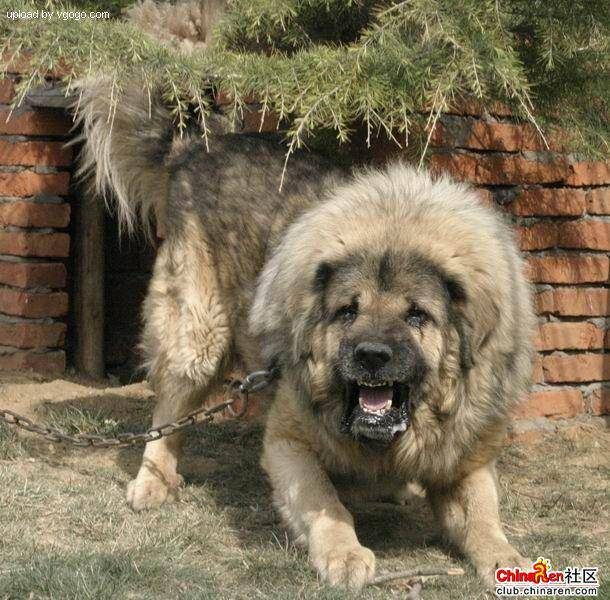

In [ ]:
#One more check


Image(filenames[9000])

In [ ]:
labels_csv["breed"][9000]

'tibetan_mastiff'

Turnign data labels into numbers

In [ ]:
#Check if the number of lables matches the number of filenames
import numpy as np
labels=labels_csv["breed"].to_numpy()

if len(labels)==len(filenames):
  print("Number of lables matches number of filenames")
else:
   print("numebr of labels does not match number of filenamnes, check directories!")

Number of lables matches number of filenames


In [ ]:
#find hte nunique label values

unique_breeds=np.unique(labels)
len(unique_breeds)

120

In [ ]:
#Turn a single label into an arary of booleans
print(labels[0])
labels[0]==unique_breeds

In [ ]:
#turn every label inot a boolean array

In [ ]:
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [ ]:
# turning boolena  into integers

In [ ]:
print(labels[0])
print(np.where(unique_breeds==labels[0]))  #incdex of label
print(boolean_labels[0].argmax()) #index where the label occurs in bool array
print(boolean_labels[0].astype(int))  #there will be a 1 where the sample label occurs

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [ ]:
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [ ]:
## Creating our own validation set

In [ ]:
# setup x and y valiables
x=filenames
y=boolean_labels

In [ ]:
len(filenames)

10222

In [ ]:
### experimenting with 1000 images and incerase as needed

In [ ]:
NUM_IMAGES= 1000 #@param {"type": "slider","min": 1000,"max": 10000,"step": 1000}

In [ ]:
#lets split our data into train and vlidation sets
from sklearn.model_selection import train_test_split

x_train,x_val,y_train,y_val=train_test_split(x[:NUM_IMAGES],y[:NUM_IMAGES],test_size=0.2,random_state=42)
len(x_train),len(x_val),len(y_train),len(y_val) #necessary to check the total

(800, 200, 800, 200)

In [ ]:
# lets have a geez at thet training data
x_train[:5],y_train[:2]

(['/content/drive/MyDrive/Classroom/train/00bee065dcec471f26394855c5c2f3de.jpg',
  '/content/drive/MyDrive/Classroom/train/0d2f9e12a2611d911d91a339074c8154.jpg',
  '/content/drive/MyDrive/Classroom/train/1108e48ce3e2d7d7fb527ae6e40ab486.jpg',
  '/content/drive/MyDrive/Classroom/train/0dc3196b4213a2733d7f4bdcd41699d3.jpg',
  '/content/drive/MyDrive/Classroom/train/146fbfac6b5b1f0de83a5d0c1b473377.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, Fa

In [ ]:
### preprocessing our images

# 1) take the image filepath as imput
# use tensorflow to erad the file and save it to a variable image
# turn our image into tensors
# resize theimage to be a shape of (224,224)
# return the modified image

In [ ]:
#convert an image to a numpy array